# Tutorial 5: SBI in Action — Inferring How a Ball Was Thrown

**Course:** AI4Science — Simulation-Based Inference

---

### The story

You watch a ball land at a certain distance $d$ and bounce to a height $h$.
You want to figure out: *at what angle $\theta$ and speed $v_0$ was it thrown?*

The catch: there's **air drag** (unknown coefficient) and **wind** (unknown speed),
and you can't observe these directly. They are **nuisance parameters** that you
must marginalise over.

### SBI concepts demonstrated in this notebook
1. **Building a physics simulator** (Euler integration of projectile with drag & wind)
2. **Amortised NPE** — infer angle & speed for many observations, no retraining
3. **Nuisance parameters** — marginalise over drag and wind automatically
4. **Sequential inference** — focus on one observation with SNPE-C
5. **Diagnostics** — SBC rank histograms to validate the posterior

> Adapted from and inspired by the ball-throw example in
> Deistler et al. (2025), *Simulation-Based Inference: A Practical Guide*, arXiv:2508.12939.

> **Runtime:** Select **GPU** in Colab: *Runtime > Change runtime type > T4 GPU*


In [ ]:
!pip install -q sbi torch matplotlib corner

import torch
import math
import time
import numpy as np
import matplotlib.pyplot as plt
from sbi.utils import BoxUniform
from sbi.inference import NPE, simulate_for_sbi
from sbi.analysis import pairplot
from sbi.utils.user_input_checks import process_prior, process_simulator, check_sbi_inputs

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
torch.manual_seed(42)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 460.0/460.0 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
 

## Part 1: The Physics Simulator

We simulate a ball thrown from height $y_0 = 1.8\,$m with:
- **Throwing angle** $\theta$ (degrees above horizontal)
- **Throwing speed** $v_0$ (m/s) [Professional baseball pitchers typically throw with an average speed of around 150 km/h!]
- **Drag coefficient** $C_d$ (dimensionless, models air resistance)
- **Wind speed** $w$ (m/s, positive = tailwind, negative = headwind)

The ball experiences gravity and quadratic drag:
$$\vec{F} = -m g \hat{y} - \tfrac{1}{2} \rho C_d A \|\vec{v}_{\rm rel}\| \vec{v}_{\rm rel}$$
where $\vec{v}_{\rm rel} = \vec{v} - w\hat{x}$ is velocity relative to the air.

**Observables** (what we "measure" when the ball lands):
- Landing distance $d$ (metres)
- Impact speed $v_f$ (m/s)

These two numbers are our data $x = (d, v_f)$. The simulator maps
$(\theta, v_0, C_d, w) \to (d, v_f)$ stochastically (small measurement noise added).


In [ ]:
def ball_simulator(params, dt=0.005):
    # Simulate a thrown ball with drag and wind. Returns (distance, impact_speed).

    # params: (batch, 4) tensor with columns [angle_deg, speed, drag_coeff, wind]
    #
    batch = params.shape[0]
    dev = params.device

    angle_deg = params[:, 0]
    v0        = params[:, 1]
    Cd        = params[:, 2]
    wind      = params[:, 3]

    # Constants
    g = 9.81
    rho = 1.2      # air density kg/m^3
    m = 0.145      # baseball mass kg
    r = 0.037      # baseball radius m
    A = math.pi * r**2
    y0 = 1.8       # release height m

    # Initial conditions
    angle_rad = angle_deg * math.pi / 180.0
    vx = v0 * torch.cos(angle_rad)
    vy = v0 * torch.sin(angle_rad)
    x = torch.zeros(batch).to(dev)
    y = torch.full((batch,), y0).to(dev)

    # Track which balls are still in flight
    active = torch.ones(batch, dtype=torch.bool).to(dev)
    landing_x = torch.zeros(batch).to(dev)
    landing_v = torch.zeros(batch).to(dev)

    for _ in range(5000):  # max steps
        if not active.any():
            break

        # Velocity relative to wind
        vx_rel = vx - wind
        vy_rel = vy
        v_rel = torch.sqrt(vx_rel**2 + vy_rel**2 + 1e-8)

        # Drag acceleration (opposing relative velocity)
        drag_factor = 0.5 * rho * Cd * A / m
        ax = -drag_factor * v_rel * vx_rel
        ay = -g - drag_factor * v_rel * vy_rel

        # Euler step
        vx = vx + ax * dt
        vy = vy + ay * dt
        x = x + vx * dt
        y = y + vy * dt

        # Check landing
        just_landed = active & (y <= 0)
        if just_landed.any():
            landing_x[just_landed] = x[just_landed]
            landing_v[just_landed] = torch.sqrt(vx[just_landed]**2 + vy[just_landed]**2)
            active[just_landed] = False

    # Balls that never landed (shouldn't happen with reasonable params)
    landing_x[active] = x[active]
    landing_v[active] = torch.sqrt(vx[active]**2 + vy[active]**2)

    # Add small measurement noise
    landing_x = landing_x + 0.3 * torch.randn(batch, device=dev)
    landing_v = landing_v + 0.5 * torch.randn(batch, device=dev)

    return torch.stack([landing_x, landing_v], dim=1)

Test throw: angle=45 deg, speed=20 m/s, Cd=0.4, wind=0
  -> distance = 35.0 m, impact speed = 17.5 m/s
RK4 simulator defined (dt=0.04, ~250 steps)
RK4-fixed simulator defined (dt=0.02, 500 steps, no branching)
Euler-nobranch simulator defined (fixed 1200 steps)


### Visualise: how angle and speed affect the landing distance

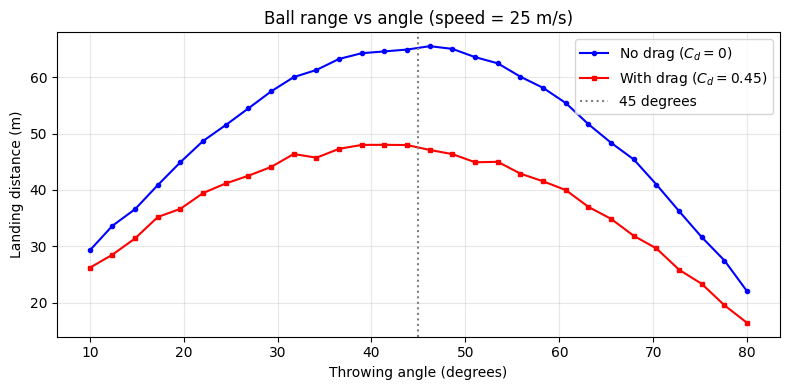

With drag, the optimal angle shifts below 45 degrees!


In [ ]:
# Sweep angle for fixed speed, no drag
angles = torch.linspace(10, 80, 30)
distances_nodrag = []
distances_drag = []

for a in angles:
    p_nodrag = torch.tensor([[a.item(), 25.0, 0.0, 0.0]])   # no drag
    p_drag   = torch.tensor([[a.item(), 25.0, 0.45, 0.0]])   # with drag
    distances_nodrag.append(ball_simulator(p_nodrag)[0, 0].item())
    distances_drag.append(ball_simulator(p_drag)[0, 0].item())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(angles.numpy(), distances_nodrag, 'b-o', ms=3, label="No drag ($C_d=0$)")
ax.plot(angles.numpy(), distances_drag, 'r-s', ms=3, label="With drag ($C_d=0.45$)")
ax.axvline(45, color='gray', ls=':', label="45 degrees")
ax.set_xlabel("Throwing angle (degrees)")
ax.set_ylabel("Landing distance (m)")
ax.set_title("Ball range vs angle (speed = 25 m/s)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print("With drag, the optimal angle shifts below 45 degrees!")


## Part 2: Basic NPE — Infer Angle and Speed (Known Drag & Wind)

First, the simple case: assume we **know** drag ($C_d = 0.45$) and wind ($w = 0$).
The only unknowns are the throwing **angle** and **speed**.


In [ ]:
# Prior over angle (15-75 deg) and speed (10-35 m/s)
prior_2d = BoxUniform(
    low=torch.tensor([15.0, 10.0]),
    high=torch.tensor([75.0, 35.0])
)

# Wrapper: fix Cd=0.45, wind=0, only angle and speed are free
def sim_known_conditions(theta):
    Cd = torch.full((theta.shape[0], 1), 0.45)
    wind = torch.zeros(theta.shape[0], 1)
    full_params = torch.cat([theta, Cd, wind], dim=1)
    return ball_simulator(full_params)

prior_2d_proc, _, prn2 = process_prior(prior_2d)
sim_2d = process_simulator(sim_known_conditions, prior_2d_proc, prn2)
check_sbi_inputs(sim_2d, prior_2d_proc)

# Generate training data
theta_2d, x_2d = simulate_for_sbi(sim_2d, prior_2d_proc, num_simulations=15_000)
print(f"Training data: {theta_2d.shape[0]} throws")
print(f"  theta (angle, speed): shape {theta_2d.shape}")
print(f"  x (distance, impact_v): shape {x_2d.shape}")


  0%|          | 0/15000 [00:00<?, ?it/s]

Training data: 15000 throws
  theta (angle, speed): shape torch.Size([15000, 2])
  x (distance, impact_v): shape torch.Size([15000, 2])


In [ ]:
# Train NPE
inference_2d = NPE(prior_2d_proc, density_estimator="nsf")
inference_2d.append_simulations(theta_2d, x_2d)
inference_2d.train(show_train_summary=False)
posterior_2d = inference_2d.build_posterior()
print("Posterior trained!")


 Neural network successfully converged after 132 epochs.Posterior trained!


### Infer angle and speed from a synthetic observation

True: angle=35 deg, speed=22 m/s
Observed: distance=38.9 m, impact speed=17.5 m/s


  0%|          | 0/10000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at ../aten/src/ATen/native/BatchLinearAlgebra.cpp:2190.)
  outputs, _ = torch.triangular_solve(
/tmp/ipykernel_676/2259346524.py:9: DeprecationWarning: you passed deprecated arguments **kwargs: ['points_colors'], use fig_kwargs instead. We continue calling the deprecated pairplot function
  fig, axes = pairplot(


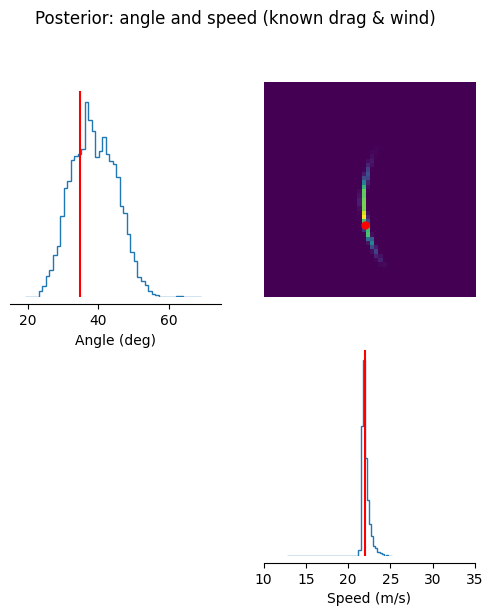

Red cross = true values. The posterior should concentrate around them.


In [ ]:
# True parameters and synthetic observation
theta_true_2d = torch.tensor([35.0, 22.0])
x_o_2d = sim_known_conditions(theta_true_2d.unsqueeze(0))
print(f"True: angle={theta_true_2d[0]:.0f} deg, speed={theta_true_2d[1]:.0f} m/s")
print(f"Observed: distance={x_o_2d[0,0]:.1f} m, impact speed={x_o_2d[0,1]:.1f} m/s")

samples_2d = posterior_2d.sample((10_000,), x=x_o_2d)

fig, axes = pairplot(
    samples_2d.numpy(),
    limits=[[15, 75], [10, 35]],
    labels=["Angle (deg)", "Speed (m/s)"],
    points=theta_true_2d.numpy(),
    points_colors=["red"],
    figsize=(6, 6)
)
plt.suptitle("Posterior: angle and speed (known drag & wind)", y=1.02)
plt.show()
print("Red cross = true values. The posterior should concentrate around them.")


In [ ]:
!pip install corner

## Part 3: Amortisation — Many Throws, One Network

Imagine you're a baseball scout watching many different throws.
The amortised posterior instantly gives you angle and speed estimates
for each throw — **no retraining**.


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

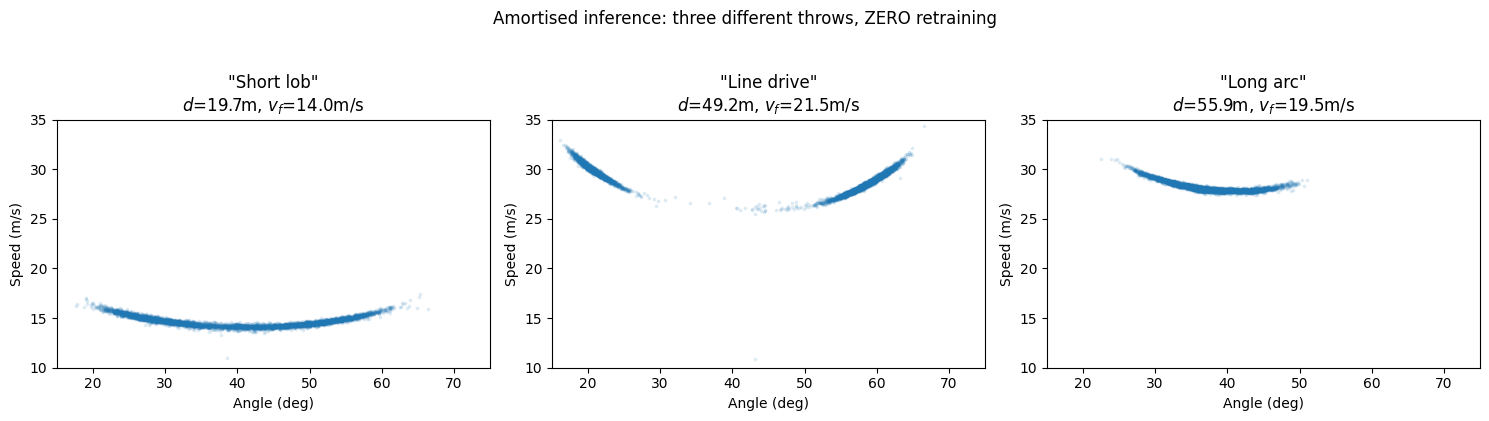

In [ ]:
# Three different "observations"
throws = {
    "Short lob":   sim_known_conditions(torch.tensor([[55.0, 15.0]])),
    "Line drive":  sim_known_conditions(torch.tensor([[20.0, 30.0]])),
    "Long arc":    sim_known_conditions(torch.tensor([[40.0, 28.0]])),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (name, x_obs) in enumerate(throws.items()):
    samples = posterior_2d.sample((5000,), x=x_obs)
    ax = axes[i]
    ax.scatter(samples[:, 0].numpy(), samples[:, 1].numpy(), alpha=0.1, s=3)
    ax.set_xlim(15, 75); ax.set_ylim(10, 35)
    ax.set_xlabel("Angle (deg)"); ax.set_ylabel("Speed (m/s)")
    ax.set_title(f'"{name}"\n$d$={x_obs[0,0]:.1f}m, $v_f$={x_obs[0,1]:.1f}m/s')
plt.suptitle("Amortised inference: three different throws, ZERO retraining", y=1.04)
plt.tight_layout(); plt.show()


## Part 4: Nuisance Parameters — Unknown Drag and Wind

Now the realistic case: we **don't know** the drag coefficient or the wind speed.
These are **nuisance parameters** — they affect the data but we don't care about
inferring them. We only want angle and speed.

**The SBI trick:** simulate with all 4 parameters, but only pass
$(\theta_{\rm angle}, v_0)$ to the network. The marginalisation over $(C_d, w)$
happens automatically through the variance in the training data.


In [ ]:
# Full 4D prior
prior_4d = BoxUniform(
    low=torch.tensor([15.0, 10.0, 0.2, -5.0]),   # angle, speed, Cd, wind
    high=torch.tensor([75.0, 35.0, 0.6, 5.0])
)

def sim_full(theta):
    return ball_simulator(theta)

prior_4d_proc, _, prn4 = process_prior(prior_4d)
sim_4d = process_simulator(sim_full, prior_4d_proc, prn4)

# Simulate all 4 params
theta_4d, x_4d = simulate_for_sbi(sim_4d, prior_4d_proc, num_simulations=20_000)

# MARGINAL NPE: only pass the first 2 params (angle, speed) to the network
prior_2d_marginal = BoxUniform(
    low=torch.tensor([15.0, 10.0]),
    high=torch.tensor([75.0, 35.0])
)
prior_2d_m, _, prn2m = process_prior(prior_2d_marginal)

inference_marg = NPE(prior_2d_m, density_estimator="nsf")
inference_marg.append_simulations(theta_4d[:, :2], x_4d)  # only angle & speed!
inference_marg.train(show_train_summary=False)
posterior_marg = inference_marg.build_posterior()
print("Marginal posterior trained (nuisance Cd and wind marginalised out)!")


  0%|          | 0/20000 [00:00<?, ?it/s]

 Neural network successfully converged after 77 epochs.Marginal posterior trained (nuisance Cd and wind marginalised out)!


### Compare: known vs unknown conditions

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

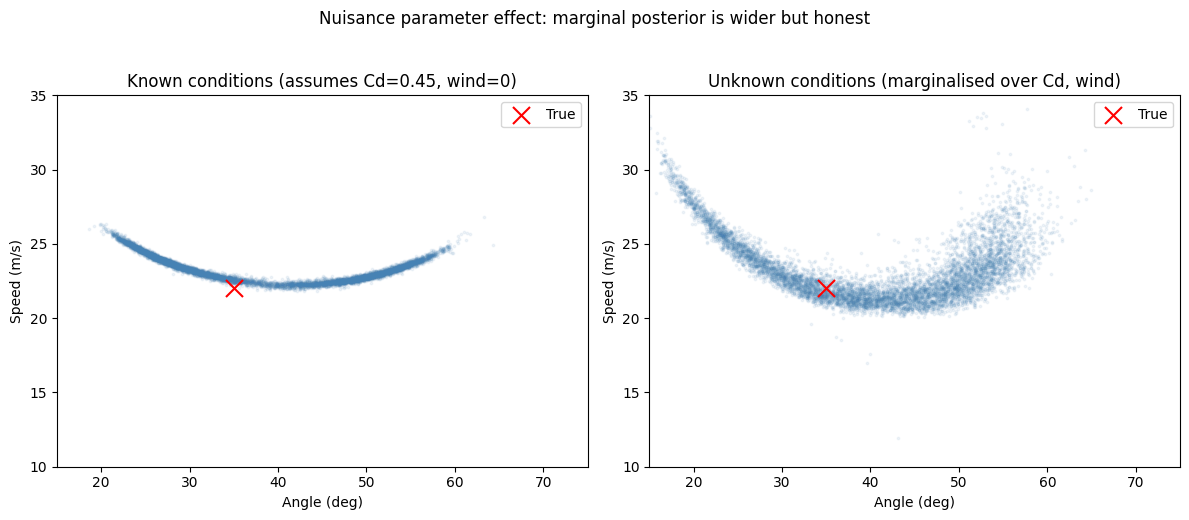

Left:  narrow but WRONG (ignores unknown wind=2 m/s tailwind)
Right: wider but CORRECT (properly accounts for unknown drag and wind)


In [ ]:
# Observation generated with specific (unknown) Cd and wind
theta_true_4d = torch.tensor([35.0, 22.0, 0.45, 2.0])  # angle, speed, Cd=0.45, tailwind=2
x_o_4d = sim_full(theta_true_4d.unsqueeze(0))

samples_known = posterior_2d.sample((8000,), x=x_o_4d)    # assumes Cd=0.45, wind=0
samples_marg  = posterior_marg.sample((8000,), x=x_o_4d)  # marginalises over Cd, wind

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, samp, title in [(axes[0], samples_known, "Known conditions (assumes Cd=0.45, wind=0)"),
                         (axes[1], samples_marg, "Unknown conditions (marginalised over Cd, wind)")]:
    ax.scatter(samp[:, 0].numpy(), samp[:, 1].numpy(), alpha=0.08, s=3, c="steelblue")
    ax.scatter([35], [22], color="red", marker="x", s=150, zorder=5, label="True")
    ax.set_xlim(15, 75); ax.set_ylim(10, 35)
    ax.set_xlabel("Angle (deg)"); ax.set_ylabel("Speed (m/s)")
    ax.set_title(title); ax.legend()

plt.suptitle("Nuisance parameter effect: marginal posterior is wider but honest", y=1.03)
plt.tight_layout(); plt.show()
print("Left:  narrow but WRONG (ignores unknown wind=2 m/s tailwind)")
print("Right: wider but CORRECT (properly accounts for unknown drag and wind)")


## Part 5: Sequential Inference (SNPE-C)

For one specific observation, we can be more simulation-efficient by
focusing the proposal on regions consistent with that observation.


In [ ]:
# Prior over angle (15-75 deg) and speed (10-35 m/s)
prior_2d = BoxUniform(
    low=torch.tensor([15.0, 10.0]),
    high=torch.tensor([75.0, 35.0])
)

# Wrapper: fix Cd=0.45, wind=0, only angle and speed are free
def sim_known_conditions(theta):
    Cd = torch.full((theta.shape[0], 1), 0.45)
    wind = torch.zeros(theta.shape[0], 1)
    full_params = torch.cat([theta, Cd, wind], dim=1)
    return ball_simulator(full_params)

# True parameters and synthetic observation
theta_true_2d = torch.tensor([35.0, 22.0])
x_o_2d = sim_known_conditions(theta_true_2d.unsqueeze(0))
print(f"True: angle={theta_true_2d[0]:.0f} deg, speed={theta_true_2d[1]:.0f} m/s")
print(f"Observed: distance={x_o_2d[0,0]:.1f} m, impact speed={x_o_2d[0,1]:.1f} m/s")


# Use a broad prior on angle and speed
prior_broad = BoxUniform(
    low=torch.tensor([5.0, 5.0]),
    high=torch.tensor([85.0, 40.0])
)
prior_broad_proc, _, prn_b = process_prior(prior_broad)

# Target observation
x_o_seq = x_o_2d  # reuse from Part 2
print(f"Target observation: d={x_o_seq[0,0]:.1f} m, v_f={x_o_seq[0,1]:.1f} m/s")

# Multi-round SNPE-C
num_rounds = 3
sims_per_round = 1000
inference_seq = NPE(prior_broad_proc, density_estimator="nsf")
proposal = prior_broad_proc
posteriors_seq = []

for r in range(num_rounds):
    theta_r, x_r = simulate_for_sbi(
        process_simulator(sim_known_conditions, prior_broad_proc, prn_b),
        proposal, num_simulations=sims_per_round
    )
    inference_seq.append_simulations(theta_r, x_r, proposal=proposal)
    de = inference_seq.train(show_train_summary=False)
    post_r = inference_seq.build_posterior(de)
    posteriors_seq.append(post_r)
    proposal = post_r.set_default_x(x_o_seq)
    s = post_r.sample((500,), x=x_o_seq)
    print(f"Round {r+1}: mean=[{s[:,0].mean():.1f} deg, {s[:,1].mean():.1f} m/s], "
          f"std=[{s[:,0].std():.1f}, {s[:,1].std():.1f}]")


True: angle=35 deg, speed=22 m/s
Observed: distance=38.7 m, impact speed=17.2 m/s
Target observation: d=38.7 m, v_f=17.2 m/s


  0%|          | 0/1000 [00:00<?, ?it/s]

 Neural network successfully converged after 221 epochs.

  0%|          | 0/500 [00:00<?, ?it/s]

Round 1: mean=[37.6 deg, 21.3 m/s], std=[6.7, 0.9]


...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Using SNPE-C with atomic loss
 Neural network successfully converged after 34 epochs.

  0%|          | 0/500 [00:00<?, ?it/s]

Round 3: mean=[39.1 deg, 21.9 m/s], std=[6.1, 0.6]


  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

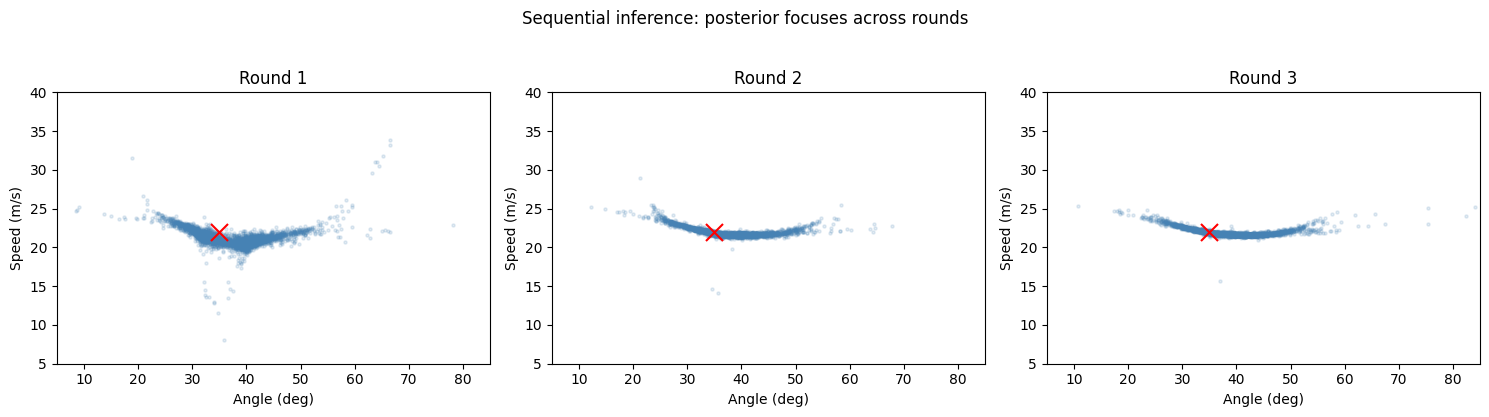

In [ ]:
# Visualise focusing
fig, axes = plt.subplots(1, num_rounds, figsize=(5*num_rounds, 4))
for r, post in enumerate(posteriors_seq):
    s = post.sample((3000,), x=x_o_seq)
    ax = axes[r]
    ax.scatter(s[:, 0].numpy(), s[:, 1].numpy(), alpha=0.15, s=5, c="steelblue")
    ax.scatter([theta_true_2d[0].item()], [theta_true_2d[1].item()],
               color="red", marker="x", s=150, zorder=5)
    ax.set_xlim(5, 85); ax.set_ylim(5, 40)
    ax.set_xlabel("Angle (deg)"); ax.set_ylabel("Speed (m/s)")
    ax.set_title(f"Round {r+1}")
plt.suptitle("Sequential inference: posterior focuses across rounds", y=1.03)
plt.tight_layout(); plt.show()


## Part 6: Diagnostics — Is Our Posterior Trustworthy?

We run **Simulation-Based Calibration (SBC)** on the amortised posterior from Part 2.
If the rank histograms are uniform, the posterior is well-calibrated.


Running SBC with 500 calibration throws...


/usr/local/lib/python3.12/dist-packages/sbi/utils/diagnostics_utils.py:45: UserWarning: Capping max_sampling_batch_size from 10000 to 200 to avoid excessive memory usage.
  posterior_samples = posterior.sample_batched(


Drawing 2000 samples for 500 observations:   0%|          | 0/2000 [00:00<?, ?it/s]

Calculating ranks for 500 SBC samples:   0%|          | 0/500 [00:00<?, ?it/s]

Done!


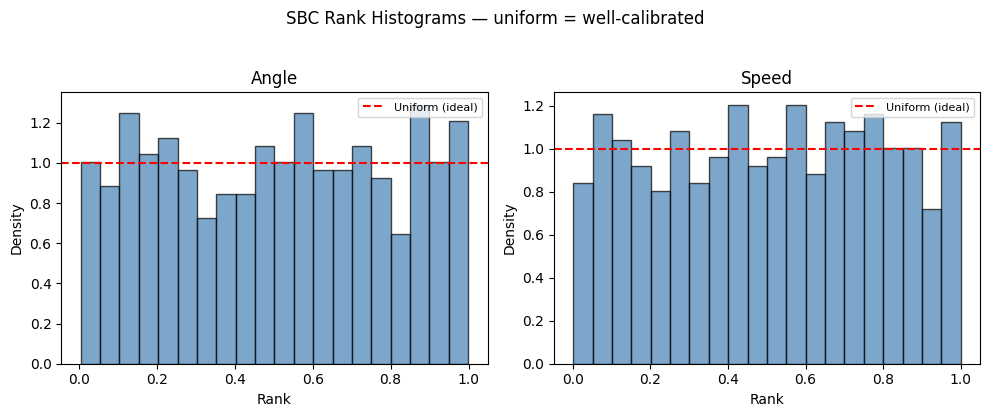

{'ks_pvals': tensor([0.8645, 0.9288]),
 'c2st_ranks': tensor([0.5220, 0.5080], dtype=torch.float64),
 'c2st_dap': tensor([0.4860, 0.5370], dtype=torch.float64)}

In [ ]:
from sbi.diagnostics import run_sbc, check_sbc

# Generate calibration set
num_sbc = 500
num_posterior_samples = 2000
thetas_cal = prior_2d_proc.sample((num_sbc,))
xs_cal = torch.stack([sim_2d(t.unsqueeze(0)).squeeze() for t in thetas_cal])

print(f"Running SBC with {num_sbc} calibration throws...")
ranks, dap = run_sbc(thetas_cal, xs_cal, posterior_2d, num_posterior_samples=num_posterior_samples)
print("Done!")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
param_names = ["Angle", "Speed"]
for d in range(2):
    ax = axes[d]
    ax.hist(ranks[:, d].numpy()/num_posterior_samples, bins=20, density=True, alpha=0.7,
            edgecolor="black", lw=0.5, color="steelblue")
    ax.axhline(1.0, color="red", ls="--", lw=1.5, label="Uniform (ideal)")
    ax.set_xlabel("Rank"); ax.set_ylabel("Density")
    ax.set_title(f"{param_names[d]}"); ax.legend(fontsize=8)

plt.suptitle("SBC Rank Histograms — uniform = well-calibrated", y=1.03)
plt.tight_layout(); plt.show()

check_sbc(ranks, thetas_cal, dap, num_posterior_samples=num_posterior_samples)


## Summary: One Physics Problem, Five SBI Concepts

| Part | SBI concept | What we saw |
|------|-------------|-------------|
| 1 | Simulator design | Euler integration of projectile with drag & wind |
| 2 | Basic NPE | Inferred angle & speed from landing distance + impact speed |
| 3 | Amortisation | Same network instantly analysed three different throws |
| 4 | Nuisance parameters | Marginalised over unknown drag & wind by excluding them from the network |
| 5 | Sequential inference | SNPE-C focused the posterior across 3 rounds with 1000 sims each |
| 6 | Diagnostics | SBC rank histograms validated that the amortised posterior is calibrated |

**The ball throw is simple enough to understand intuitively, but rich enough to demonstrate
the full SBI workflow from Lecture II.**


## Exercises

**Exercise 1:** Add a 5th parameter: release height $y_0$ (prior: 1.5-2.1 m).
Train a marginal posterior for angle and speed only. How does it compare?

**Exercise 2:** Use `density_estimator="maf"` instead of `"nsf"`. Compare training time and posterior.

**Exercise 3:** Generate an observation with extreme wind ($w = 18$ m/s).
Does the marginal posterior (Part 4) still cover the true angle and speed?


<details>
<summary><b>Solution -- Exercise 1: Release height as nuisance</b></summary>

Adding $y_0$ as a 5th nuisance parameter increases the variance of the training data slightly.
The marginal posterior for angle and speed should be a bit wider than the 4-parameter version,
since $y_0$ uncertainty adds noise to the landing distance.
</details>

In [ ]:
# === SOLUTION: Exercise 1 ===
prior_5d = BoxUniform(
    low=torch.tensor([15.0, 10.0, 0.2, -5.0, 1.5]),
    high=torch.tensor([75.0, 35.0, 0.6,  5.0, 2.1])
)
prior_5d_proc, _, prn5 = process_prior(prior_5d)

# MARGINAL NPE: only pass the first 2 params (angle, speed) to the network
prior_2d_marginal = BoxUniform(
    low=torch.tensor([15.0, 10.0]),
    high=torch.tensor([75.0, 35.0])
)
prior_2d_m, _, prn2m = process_prior(prior_2d_marginal)

def sim_5d(theta):
    # Override y0 in the simulator
    batch = theta.shape[0]
    results = []
    for i in range(batch):
        angle, v0, Cd, wind, y0 = theta[i]
        # Mini Euler for single throw with custom y0
        vx = v0 * math.cos(angle.item() * math.pi / 180)
        vy = v0 * math.sin(angle.item() * math.pi / 180)
        x_pos, y_pos = 0.0, y0.item()
        dt = 0.005
        for _ in range(5000):
            vrel_x = vx - wind.item()
            v_rel = math.sqrt(vrel_x**2 + vy**2 + 1e-8)
            drag = 0.5 * 1.2 * Cd.item() * math.pi * 0.037**2 / 0.145
            vx += (-drag * v_rel * vrel_x) * dt
            vy += (-9.81 - drag * v_rel * vy) * dt
            x_pos += vx * dt
            y_pos += vy * dt
            if y_pos <= 0:
                break
        results.append([x_pos + 0.3*np.random.randn(), math.sqrt(vx**2+vy**2) + 0.5*np.random.randn()])
    return torch.tensor(results, dtype=torch.float32)

sim_5d_fn = process_simulator(sim_5d, prior_5d_proc, prn5)
theta_5d, x_5d = simulate_for_sbi(sim_5d_fn, prior_5d_proc, num_simulations=15_000)

inf_5d = NPE(prior_2d_m, density_estimator="nsf")
inf_5d.append_simulations(theta_5d[:, :2], x_5d)
inf_5d.train(show_train_summary=False)
post_5d = inf_5d.build_posterior()

# Compare
x_test = sim_known_conditions(theta_true_2d.unsqueeze(0))
s_4 = posterior_marg.sample((5000,), x=x_test)
s_5 = post_5d.sample((5000,), x=x_test)

print(f"4-param nuisance (Cd, wind):     angle std={s_4[:,0].std():.1f}, speed std={s_4[:,1].std():.1f}")
print(f"5-param nuisance (Cd, wind, y0): angle std={s_5[:,0].std():.1f}, speed std={s_5[:,1].std():.1f}")
print("More nuisance parameters -> slightly wider posterior (more honest uncertainty)")


  0%|          | 0/15000 [00:00<?, ?it/s]

 Neural network successfully converged after 100 epochs.

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

4-param nuisance (Cd, wind):     angle std=10.1, speed std=1.9
5-param nuisance (Cd, wind, y0): angle std=10.3, speed std=1.9
More nuisance parameters -> slightly wider posterior (more honest uncertainty)


<details>
<summary><b>Solution -- Exercise 2: MAF vs NSF</b></summary>

MAF uses affine elementwise transforms, NSF uses spline transforms.
NSF is typically more expressive per layer, so it may need fewer layers.
For this 2D problem, both should work well.
</details>

In [ ]:
# === SOLUTION: Exercise 2 ===
t0 = time.time()
inf_maf = NPE(prior_2d_proc, density_estimator="maf")
inf_maf.append_simulations(theta_2d, x_2d)
inf_maf.train(show_train_summary=False)
post_maf = inf_maf.build_posterior()
maf_time = time.time() - t0

s_nsf = posterior_2d.sample((5000,), x=x_o_2d)
s_maf = post_maf.sample((5000,), x=x_o_2d)

print(f"NSF training time: ~{15:.0f}s (from earlier)")
print(f"MAF training time: {maf_time:.1f}s")
print(f"NSF posterior std: angle={s_nsf[:,0].std():.2f}, speed={s_nsf[:,1].std():.2f}")
print(f"MAF posterior std: angle={s_maf[:,0].std():.2f}, speed={s_maf[:,1].std():.2f}")


 Neural network successfully converged after 169 epochs.

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

NSF training time: ~15s (from earlier)
MAF training time: 172.8s
NSF posterior std: angle=4.07, speed=0.37
MAF posterior std: angle=6.00, speed=0.52


<details>
<summary><b>Solution -- Exercise 3: Extreme wind</b></summary>

With wind=8 m/s (outside the prior range [-5, 5]), the marginal posterior may fail
because the observation is out-of-distribution. This highlights the importance of
choosing priors that cover plausible conditions.
</details>

Extreme wind observation: d=47.5 m, v_f=21.6 m/s


  0%|          | 0/5000 [00:00<?, ?it/s]

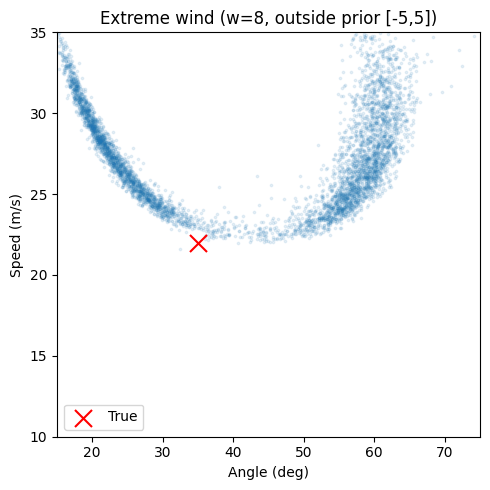

The posterior may be biased or poorly calibrated because
the observation was generated outside the training distribution.
-> Always ensure your prior covers plausible conditions!


In [ ]:
# === SOLUTION: Exercise 3 ===
theta_extreme = torch.tensor([[35.0, 22.0, 0.45, 18.0]])  # wind=18, outside prior!
x_extreme = ball_simulator(theta_extreme)
print(f"Extreme wind observation: d={x_extreme[0,0]:.1f} m, v_f={x_extreme[0,1]:.1f} m/s")

s_extreme = posterior_marg.sample((5000,), x=x_extreme)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(s_extreme[:, 0].numpy(), s_extreme[:, 1].numpy(), alpha=0.1, s=3)
ax.scatter([35], [22], color="red", marker="x", s=150, zorder=5, label="True")
ax.set_xlim(15, 75); ax.set_ylim(10, 35)
ax.set_xlabel("Angle (deg)"); ax.set_ylabel("Speed (m/s)")
ax.set_title("Extreme wind (w=8, outside prior [-5,5])")
ax.legend()
plt.tight_layout(); plt.show()
print("The posterior may be biased or poorly calibrated because")
print("the observation was generated outside the training distribution.")
print("-> Always ensure your prior covers plausible conditions!")
